# Support Vector Classifier Implementation

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
# Lets create synthetic data point
from sklearn.datasets import make_classification

In [65]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes = 2,n_clusters_per_class=1,n_redundant=0)

In [66]:
X

array([[-0.78660637,  1.73745387],
       [ 1.61314073, -1.74014697],
       [-0.41735031, -0.79899128],
       ...,
       [ 3.42461496, -1.50940319],
       [-1.20383923,  1.13903228],
       [-0.64369271,  0.44989294]])

In [67]:
y

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,

In [68]:
pd.DataFrame(X)[1]

0      1.737454
1     -1.740147
2     -0.798991
3      0.457509
4      0.709389
         ...   
995   -0.713228
996   -1.495632
997   -1.509403
998    1.139032
999    0.449893
Name: 1, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

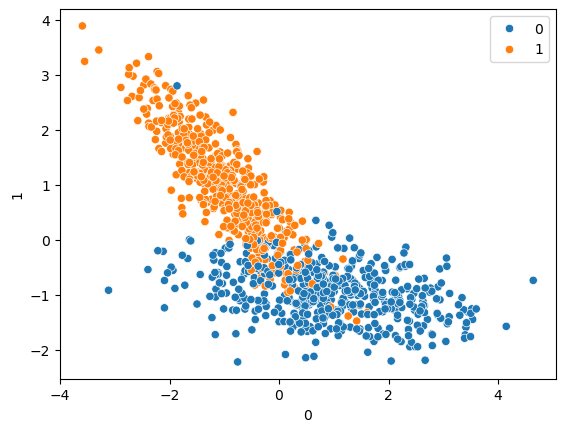

In [69]:
sns.scatterplot(
    x=pd.DataFrame(X)[0],
    y=pd.DataFrame(X)[1],
    hue=y
)

In [70]:
from sklearn.svm import SVC

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [75]:
svm_model = SVC(
    kernel='rbf',   # linear, poly, rbf
    C=1.0,
    gamma='scale'
)

In [76]:
svm_model.fit(X_train_scaled, y_train)


SVC()

In [77]:
y_pred = svm_model.predict(X_test_scaled)

In [78]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [79]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.94

Confusion Matrix:
[[93  4]
 [ 8 95]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        97
           1       0.96      0.92      0.94       103

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



## Hyperparameter tunning 

In [85]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100,1000],
    'gamma': [1, 0.1, 0.01, 0.001,0.0001],
    'kernel': ['rbf', 'linear', 'poly']
}

In [87]:
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    verbose=3,
    n_jobs=-1,
    refit=True
)


In [88]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear', 'poly']},
             verbose=3)

In [89]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Score:")
print(grid.best_score_)

Best Parameters:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Best Score:
0.9237500000000001


In [93]:
best_model = grid.best_estimator_

In [94]:
y_pred = best_model.predict(X_test_scaled)

In [95]:
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.935

Confusion Matrix:
[[91  6]
 [ 7 96]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93        97
           1       0.94      0.93      0.94       103

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200

